In [6]:
import matplotlib.pyplot as plt
import random
# --- 🏗️ THE UPGRADED PID BLUEPRINT (CLASS) ---
class RaceCar:
    def __init__(self, name, strategy, has_firewall=False, ai_weight=250):
        self.name = name
        self.strategy = strategy
        self.has_firewall = has_firewall
        self.ai_weight = ai_weight
        self.distance = 0
        self.speed = 0
        self.fuel = 100.0
        
        # Cyber Security States
        self.sensor_spoof_offset = 0  
        self.crashed = False   
        self.last_trusted_speed = 0  
        
        # 🧮 PID Controller Memory States
        self.previous_error = 0   # For the Derivative (Future)
        self.integral_error = 0   # For the Integral (Past)
        
        self.history = {'time': [], 'speed': [], 'fuel': []}

    def drive(self, current_time, is_raining):
        if self.distance >= 1000 or self.fuel <= 0 or self.crashed:
            return 
            
        # --- 🧠 THE STRATEGIES ---
        if self.strategy == 'aggressive':
            target_speed = 28 if self.fuel > 15 else 12
        elif self.strategy == 'safe': 
            target_speed = 20 if self.fuel > 10 else 12
        elif self.strategy == 'ai':
            distance_left = 1000 - self.distance
            fuel_ratio = self.fuel / max(1, distance_left) 
            calculated_speed = fuel_ratio * self.ai_weight 
            target_speed = max(10, min(calculated_speed, 32))

        if is_raining:
            target_speed = min(target_speed, 14)

        # 🛡️ The Firewall 
        raw_sensor_speed = self.speed - self.sensor_spoof_offset
        perceived_speed = raw_sensor_speed
        
        if self.has_firewall:
            speed_delta = abs(raw_sensor_speed - self.last_trusted_speed)
            if speed_delta > 15:
                perceived_speed = self.last_trusted_speed
                self.sensor_spoof_offset = 0 
            else:
                self.last_trusted_speed = raw_sensor_speed
        
        # --- 🧮 THE PID CONTROLLER ---
        # 1. Calculate current error (Present)
        error = target_speed - perceived_speed
        
        # 2. Accumulate integral error (Past)
        self.integral_error += error
        
        # ⚠️ Anti-Windup: Prevent the integral memory from growing infinitely
        self.integral_error = max(-50, min(self.integral_error, 50))
        
        # 3. Calculate derivative error (Future)
        derivative_error = error - self.previous_error
        
        # The Tuning Constants
        Kp = 0.3   # Push based on current gap
        Ki = 0.05  # Nudge based on lingering past gap
        Kd = 0.1   # Dampen based on approach speed
        
        # The final throttle/brake command
        speed_change = (Kp * error) + (Ki * self.integral_error) + (Kd * derivative_error)
        
        # Save current error for the next second's derivative calculation
        self.previous_error = error
        
        # Apply physics
        self.speed += speed_change

        if speed_change > 0:
            self.fuel -= (0.4 * speed_change)
        else:
            self.fuel -= 0.05
            
        self.distance += self.speed
        
        # 💥 Crash Condition
        if self.speed > 40:
            self.crashed = True
            self.history['time'].append(current_time)
            self.history['speed'].append(self.speed)
            self.history['fuel'].append(self.fuel)
            self.speed = 0 
            return 
        
        self.history['time'].append(current_time)
        self.history['speed'].append(self.speed)
        self.history['fuel'].append(self.fuel)

In [7]:
# --- 🧬 THE AI TRAINING CAMP (EVOLUTION LOOP) ---
def train_ai(epochs=50):
    print("\n🧠 Initiating AI Training Protocol (50 Epochs)...")
    best_weight = 150 # Start with a safe, slow baseline guess
    best_time = 999 

    for epoch in range(1, epochs + 1):
        # 1. Mutate: Tweak the weight slightly
        if epoch == 1:
            test_weight = best_weight
        else:
            # Randomly shift the weight up or down to explore new strategies
            mutation = random.uniform(-40, 40)
            test_weight = best_weight + mutation
        
        # 2. Simulate: Run a private, dry-weather race for Max
        test_car = RaceCar(f"Epoch {epoch}", "ai", ai_weight=test_weight)
        seconds = 0
        
        while test_car.distance < 1000 and test_car.fuel > 0 and not test_car.crashed:
            seconds += 1
            test_car.drive(seconds, is_raining=False)
        
        # 3. Evaluate: Did he finish? Was he faster?
        finished = test_car.distance >= 1000
        
        if finished and seconds < best_time:
            print(f"✅ Epoch {epoch:02d}: NEW RECORD! Weight {test_weight:.1f} finished in {seconds}s (Fuel left: {test_car.fuel:.1f}%)")
            best_weight = test_weight
            best_time = seconds

    print(f"🏆 Training Complete! Optimal Weight Found: {best_weight:.1f}\n")
    return best_weight

In [8]:
# --- 📊 AUTOMATED POST-RACE ANALYSIS ---
def analyze_race(cars_list):
    print("\n" + "="*45)
    print("🏆 OFFICIAL POST-RACE TELEMETRY REPORT 🏆")
    print("="*45)
    
    stats = []
    for car in cars_list:
        if len(car.history['time']) > 0:
            finished = car.distance >= 1000
            final_time = car.history['time'][-1]
            max_speed = max(car.history['speed'])
            
            stats.append({
                'name': car.name,
                'finished': finished,
                'distance': car.distance,
                'time': final_time,
                'fuel': max(0, car.fuel), 
                'max_speed': max_speed
            })
        
    stats.sort(key=lambda x: (x['finished'], -x['time'] if x['finished'] else x['distance']), reverse=True)
    
    winner = stats[0]
    print(f"🥇 WINNER: {winner['name'].upper()}!\n")
    
    print(f"{'Driver':<18} | {'Status':<10} | {'Time':<8} | {'Max Spd':<8} | {'Fuel Left'}")
    print("-" * 65)
    
    for r in stats:
        status = "FINISHED" if r['finished'] else "DNF"
        time_str = f"{r['time']}s" if r['finished'] else "N/A"
        print(f"{r['name']:<18} | {status:<10} | {time_str:<8} | {r['max_speed']:<8.1f} | {r['fuel']:.1f}%")

In [13]:
# --- 🏁 THE MAIN EVENT ---
# 1. Train the AI in the background first
perfect_ai_weight = train_ai(epochs=50)

# 2. Spawn the racers, giving Max his newly learned perfect weight
car1 = RaceCar("Aggressive Alice", "aggressive", has_firewall=False)
car2 = RaceCar("Safe Sam", "safe", has_firewall=True) 
car3 = RaceCar("ML Max (AI)", "ai", has_firewall=True, ai_weight=perfect_ai_weight) 

seconds = 0
rain_triggered = False
rain_time = 0
random_rain_start = random.randint(5, 45)

# 🎲 The Weather : Pick a random second for the rain to start (between 5s and 45s)
random_rain_start = random.randint(5, 45)

print(f"🟢 Race Started! Monitoring 3 vehicles...")
print("☁️ Weather Radar: Conditions are unpredictable today...")

while any((c.distance < 1000 and c.fuel > 0 and not c.crashed) for c in [car1, car2, car3]):
    seconds += 1
    
    # 🌧️ Unpredictable Rain Event
    if not rain_triggered and seconds >= random_rain_start:
        rain_triggered = True
        rain_time = seconds
        print(f"🌧️ [TIME: {seconds}s] DOWNPOUR! Track limits reduced to 14 m/s.")
    
    # 🏴‍☠️ Cyber Attack on Sam remains at 15s
    if seconds == 15:
        car2.sensor_spoof_offset = 25  

    car1.drive(seconds, rain_triggered)
    car2.drive(seconds, rain_triggered)
    car3.drive(seconds, rain_triggered)

print("🏁 Race Finished!")
analyze_race([car1, car2, car3])


🧠 Initiating AI Training Protocol (50 Epochs)...
✅ Epoch 01: NEW RECORD! Weight 150.0 finished in 43s (Fuel left: 86.0%)
✅ Epoch 05: NEW RECORD! Weight 180.1 finished in 38s (Fuel left: 86.0%)
✅ Epoch 13: NEW RECORD! Weight 217.8 finished in 35s (Fuel left: 85.7%)
✅ Epoch 14: NEW RECORD! Weight 228.0 finished in 34s (Fuel left: 85.5%)
✅ Epoch 18: NEW RECORD! Weight 262.4 finished in 33s (Fuel left: 84.7%)
✅ Epoch 19: NEW RECORD! Weight 285.8 finished in 32s (Fuel left: 84.4%)
✅ Epoch 24: NEW RECORD! Weight 318.8 finished in 31s (Fuel left: 84.1%)
🏆 Training Complete! Optimal Weight Found: 318.8

🟢 Race Started! Monitoring 3 vehicles...
☁️ Weather Radar: Conditions are unpredictable today...
🌧️ [TIME: 9s] DOWNPOUR! Track limits reduced to 14 m/s.
🏁 Race Finished!

🏆 OFFICIAL POST-RACE TELEMETRY REPORT 🏆
🥇 WINNER: ML MAX (AI)!

Driver             | Status     | Time     | Max Spd  | Fuel Left
-----------------------------------------------------------------
ML Max (AI)        | FINISHED

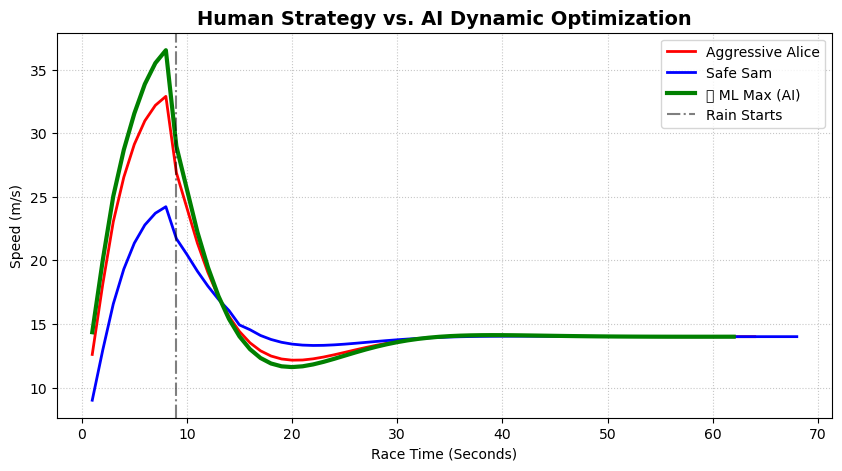

In [14]:
# --- 📈 THE VISUALIZATION ---
plt.figure(figsize=(10, 5))

plt.plot(car1.history['time'], car1.history['speed'], label=f'{car1.name}', color='red', linewidth=2)
plt.plot(car2.history['time'], car2.history['speed'], label=f'{car2.name}', color='blue', linewidth=2)
plt.plot(car3.history['time'], car3.history['speed'], label=f'🤖 {car3.name}', color='green', linewidth=3) # The AI Line

if rain_time > 0:
    plt.axvline(x=rain_time, color='black', linestyle='-.', alpha=0.5, label='Rain Starts')

plt.title("Human Strategy vs. AI Dynamic Optimization", fontsize=14, fontweight='bold')
plt.xlabel("Race Time (Seconds)")
plt.ylabel("Speed (m/s)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()